# Task 1: Exploratory Data Analysis & Business Insights

### 5 Key Insights from Telco Customer Churn
1. **Contract Loyalty:** The bar chart reveals that customers on month-to-month contracts are significantly more likely to churn compared to those on 1-year or 2-year contracts.
2. **Correlation Findings:** The heatmap shows a very strong positive correlation (0.83) between customer `tenure` and `TotalCharges`, which is logically consistent as longer-standing customers accumulate more charges over time.
3. **Distribution of Charges:** The histogram indicates that a large volume of customers falls into the lower bracket of monthly charges, but there is another significant peak around the $80-$100 range.
4. **Data Quality Check:** There were 11 hidden missing values in the `TotalCharges` column disguised as blank spaces, which had to be coerced into numerical format and imputed using the median.
5. **Tenure Trends:** The line chart demonstrates a nearly perfectly linear upward trend over time, showing consistent revenue generation across the lifespan of a retained customer's tenure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('telco_churn.csv')
print("Data loaded successfully!")

Data loaded successfully!


In [2]:
# Display basic information and summary statistics
print("--- Data Info ---")
display(df.info())

print("\n--- Statistical Summary ---")
display(df.describe(include='all'))

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

None


--- Statistical Summary ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [3]:
# 1. Remove duplicates
df = df.drop_duplicates()
print("Duplicates removed.")

# 2. Fix data types: Convert 'TotalCharges' from object (text) to numeric
# The errors='coerce' argument turns blank spaces into NaN (missing values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("'TotalCharges' data type fixed to numeric.")

Duplicates removed.
'TotalCharges' data type fixed to numeric.


In [4]:
# Check for missing values created in the previous step
missing_count = df['TotalCharges'].isnull().sum()
print(f"Missing values found: {missing_count}")

# Fill missing values in 'TotalCharges' with the median value of that column
median_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_charges)
print("Missing values filled with median.")

Missing values found: 11
Missing values filled with median.


In [5]:
# Using the IQR method on the 'TotalCharges' column
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame to keep only the rows within the bounds
original_shape = df.shape
df = df[(df['TotalCharges'] >= lower_bound) & (df['TotalCharges'] <= upper_bound)]

print(f"Outliers handled. Data shape went from {original_shape} to {df.shape}")

Outliers handled. Data shape went from (7043, 21) to (7043, 21)


In [6]:
import os

# 1. Create the 'data' folder one level back if it doesn't exist
os.makedirs('../data', exist_ok=True)

# 2. Save the final cleaned data into that folder
df.to_csv('../data/cleaned_dataset.csv', index=False)
print("Cleaned dataset successfully saved as 'cleaned_dataset.csv'!")

Cleaned dataset successfully saved as 'cleaned_dataset.csv'!


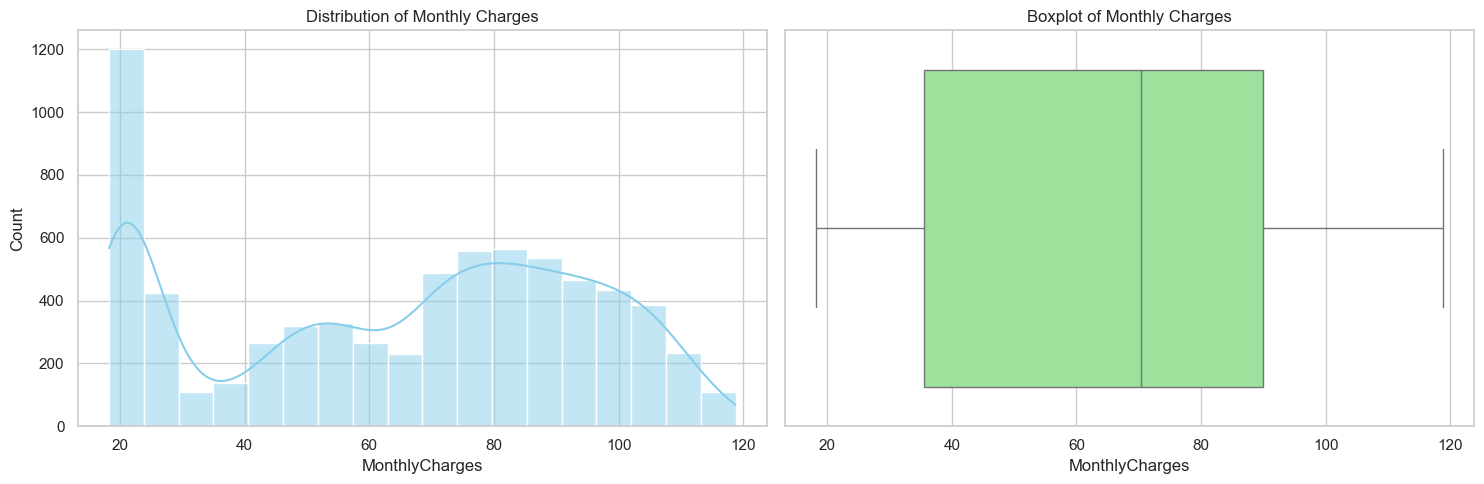

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Monthly Charges')

# Boxplot
sns.boxplot(x=df['MonthlyCharges'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Monthly Charges')

plt.tight_layout()
plt.show()

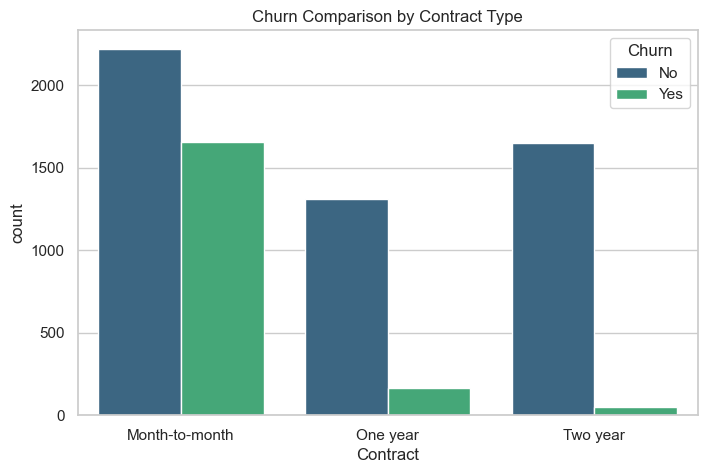

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn Comparison by Contract Type')
plt.show()

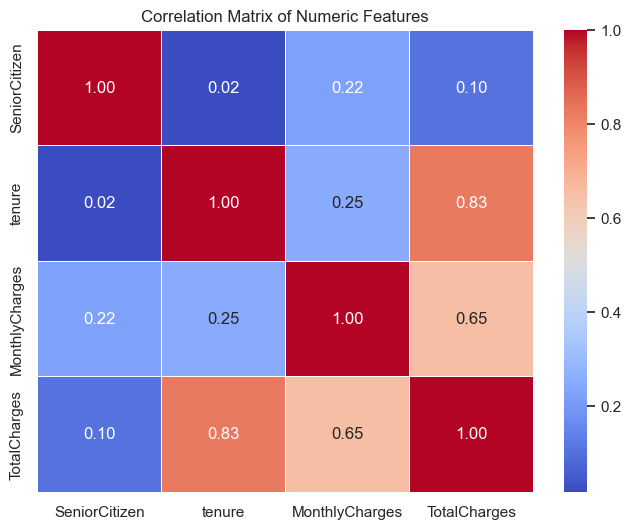

In [9]:
plt.figure(figsize=(8, 6))
# Isolate only the numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

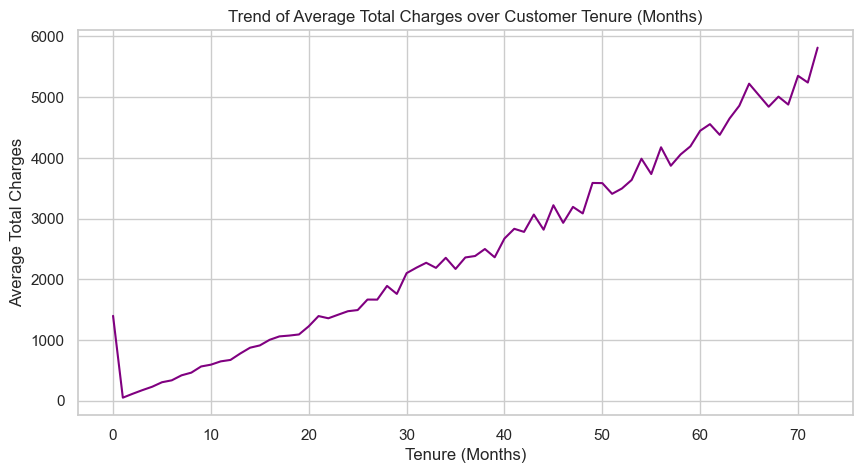

In [10]:
plt.figure(figsize=(10, 5))
# Grouping by tenure to see the trend of TotalCharges over the customer lifespan
trend_data = df.groupby('tenure')['TotalCharges'].mean().reset_index()

sns.lineplot(data=trend_data, x='tenure', y='TotalCharges', color='purple')
plt.title('Trend of Average Total Charges over Customer Tenure (Months)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Average Total Charges')
plt.show()